# Lab 4

### Understanding Uncertainty
### Shane Brosnan

In [1]:
# imports
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns
from scipy import stats
from scipy.special import gamma
import ipywidgets as widgets

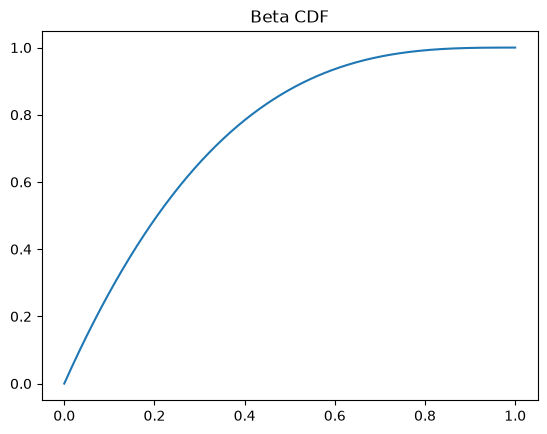

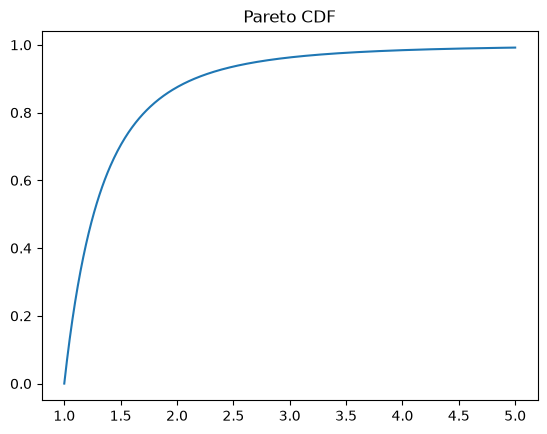

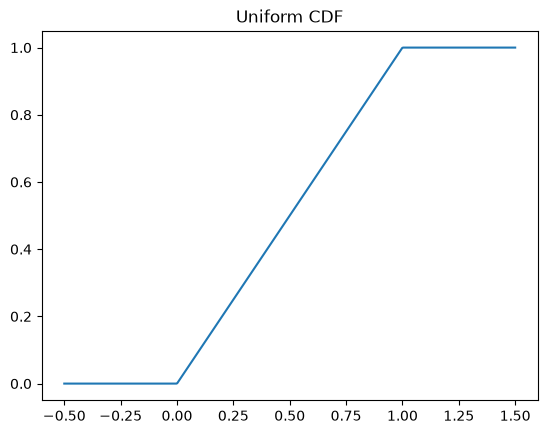

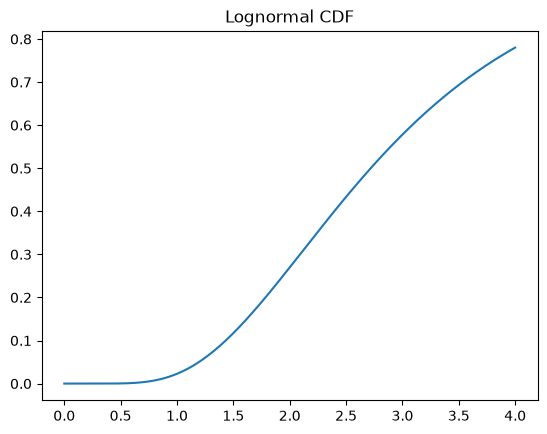

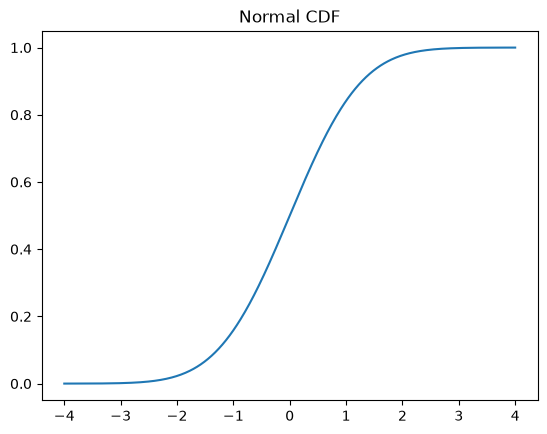

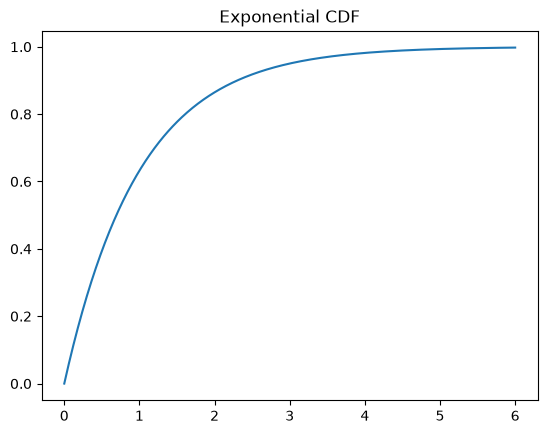

In [2]:
# plotting the 6 distributions' cdfs to compare the later problems to later (some help from Claude to find the built in scipy stats names)

# Beta distribution cdf
dist = stats.beta(a=1, b=3)
x = np.linspace(0, 1, 500)
plt.plot(x, dist.cdf(x))
plt.title("Beta CDF")
plt.show()

# Pareto distribution cdf
dist = stats.pareto(b=3, scale=1)
x = np.linspace(1, 5, 500)
plt.plot(x, dist.cdf(x))
plt.title("Pareto CDF")
plt.show()

# Uniform distribution cdf
dist = stats.uniform(loc=0, scale=1)
x = np.linspace(-0.5, 1.5, 500)
plt.plot(x, dist.cdf(x))
plt.title("Uniform CDF")
plt.show()

# Lognormal distribution cdf
dist = stats.lognorm(s=0.5, scale=np.exp(1))
x = np.linspace(0, 4, 500)
plt.plot(x, dist.cdf(x))
plt.title("Lognormal CDF")
plt.show()

# Normal distribution cdf
dist = stats.norm(loc=0, scale=1)
x = np.linspace(-4, 4, 500)
plt.plot(x, dist.cdf(x))
plt.title("Normal CDF")
plt.show()

# Exponential distribution cdf
dist = stats.expon(scale=1)
x = np.linspace(0, 6, 500)
plt.plot(x, dist.cdf(x))
plt.title("Exponential CDF")
plt.show()

### Problem 1

OK, a warm-up, just to get started.
- Set up a grid of K equally spaced values between 0 and 1, {1/K, 2/K, ..., K/K}.
- Draw a point from the grid at random with equal probability.
- For a very small K, repeat the above process n = 5_000 times, and plot the ECDF of the draws.
- What distribution does this approach as you increase K?

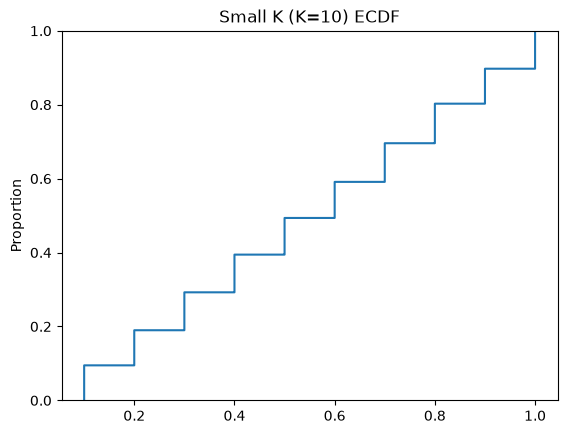

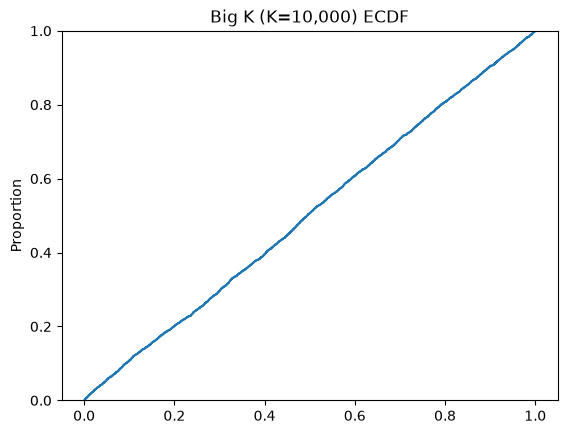

In [3]:
# setting up the grid (for small K)
small_K = 10
small_grid = np.arange(1, small_K + 1) / small_K
n = 5_000
small_draws = np.random.choice(small_grid, size=n) # using .random.choice since it picks anywhere on the grid
# plotting the ecdf of the small K
sns.ecdfplot(x = small_draws)
plt.title("Small K (K=10) ECDF")
plt.show()

# setting up the grid (for big K)
big_K = 10_000
big_grid = np.arange(1, big_K + 1) / big_K
n = 5_000
big_draws = np.random.choice(big_grid, size=n)
# plotting the ecdf of the big K
sns.ecdfplot(x = big_draws)
plt.title("Big K (K=10,000) ECDF")
plt.show()

ANSWER:

When K is small, we get an ECDF that looks like steps. It goes up in equal and steady increments, making it clear what type of slope it is creating. When K get larger, we see that the "steps" disappear and we get a straight line. So, increasing K smooths out the steps to look more like a linear line following the equation y=x. This distirbution of following a straight line at a constant slope follows the Uniform Distribution CDF. Looking at the plots above, this simulation matches the Uniform Distribution CDF the closest and follows the description of having an equal distribution over a fixed interval (here 0-1).

### Problem 2

We often study sample averages: It's one of the first statistics you calculate for any dataset. What is the distribution of the sample mean?

- Draw n = 32 values from Uniform[-sqrt(3), sqrt(3)]; these are your data. The choice of ±3 ensures each draw has mean 0 and variance 1.
- For this sample, compute the mean and multiply by np.sqrt(n).
- Repeat the above process b = 5_000 times and plot the ECDF.
- What distribution does this approach as n increases?

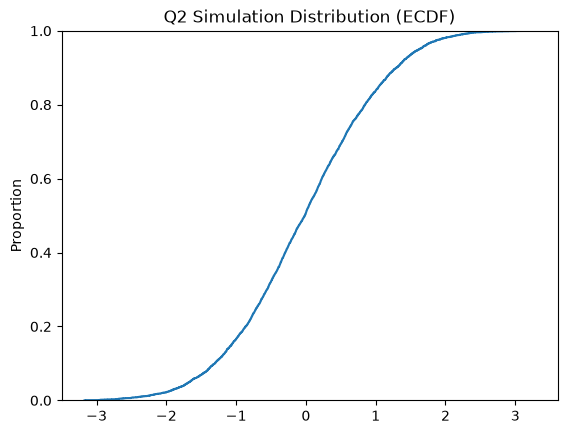

In [4]:
# defining the values specified by the problem
n = 32
b = 5_000
data = np.random.uniform(-np.sqrt(3), np.sqrt(3), size=(b, n)) # using +/- sqrt3 and .uniform like the problem said to
draws = data.mean(axis=1) * np.sqrt(n) # taking mean then multiplying by sqrtn
sns.ecdfplot(x=draws)
plt.title("Q2 Simulation Distribution (ECDF)")
plt.show()

ANSWER:

Looking at this graph, we can see that shape of the distribution looks like an "S". Moving left to right, we start close to 0 and then start to increase faster and faster, until we reach 0 where the accelerations begins to slow and then eventually plateaus around values of 3. This matches what we know the Normal Dsitribution CDF to do, and we can look at that CDF above and see that they match very closely. So, this simulation follows the normal distribution and follows the pattern of the normal cdf.

Increasing n here does not make much of a difference because we are already taking the mean for each trial. However, there are tiny changes made where the graph becomes even more like the Normal Distribution CDF.

### Problem 3

In reliability engineering, we are often concerned with the proportions of failures that occur. For example, the Challenger space shuttle exploded on January 28, 1986, when the primary and secondary o-rings failed. Floods often occur because too many levees or pumps are compromised. In this simulation, we have 40 units that each fail with probability p, and we want to study the distribution of the survivors.

- Flip n = 40 coins, which each come up heads with probability p=1/2 and tails with complementary probability.
- From the final count of heads, subtract the expected number of heads, n * p.
- Divide by the standard deviation sqrt( n * p * (1-p) ).
- Repeat the above process b = 5_000 times and plot the ECDF.
- What distribution does this approach as n increases?
- How do the results change as you adjust p?

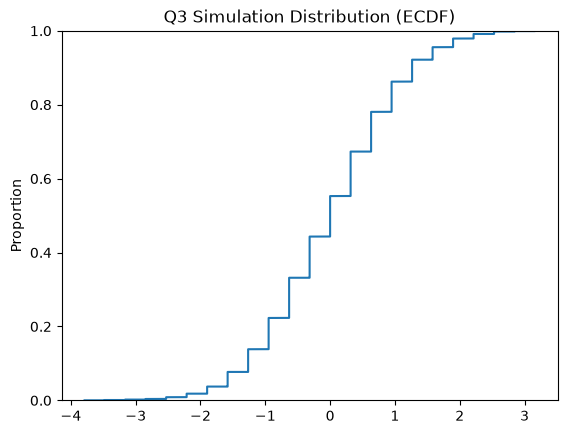

In [5]:
# defining values from the problem
n = 40
p = 1/2
b = 5_000

# simulating the coin flip with the binomial function since that is what they follow
flips = np.random.binomial(1, p, size=(b, n))
# summing the heads from the flips (sum since either 1 for heads or 0 for tails)
heads = flips.sum(axis=1)
# subtracting expected num of heads (40*0.5=20) and dividing by sd
draws = (heads - n*p) / np.sqrt(n*p * (1 - p))
sns.ecdfplot(x=draws)
plt.title("Q3 Simulation Distribution (ECDF)")
plt.show()

ANSWER:

Again, we can see the same shape forming from problem 2. The proportion starts low, then accelerates, then decelerates, and plateaus. This is the shape/story of the Normal Distribution CDF, especially since we see that the acceleration/deceleration flip occurs when x=0. So, this simulation matches the Normal Distribution CDF.

As n increases, the steps being to disappear and we get closer to the Normal Distribution CDF, similar to all other problems. At p = 1/2, the ECDF is a symmetric S-shape that crosses the 1/2 proportion at x = 0 and matches the Normal Distribution CDF. When p is moved away from 1/2, the curve stays roughly S-shaped but stops matching the Normal CDF. We can see that when p is very low, the proportion becomes much higher at x=0, meaning that the ability of survining decreases. When p is very large, the proportion of survivors at x=0 is much higher, meaning that we export more survivors.

### Problem 4

A process is running in discrete time. In each time interval of length dt, it terminates with probability r * dt, where r * dt < 1. This is called an arrival, death, or survival process, and is popular for modeling how long patients live after a procedure, whether an employee quits, or the arrival of the next goal in a sportsball match.

- For each simulation of the process, determine the period in which termination occurs.
- Convert periods to time by multiplying by dt.
- Repeat the simulation n = 5_000 times and plot the ECDF, for a value of dt close to zero (e.g. dt = 1e-3).
- What distribution does this approach as dt goes to zero?
- How do the results change as you adjust r?

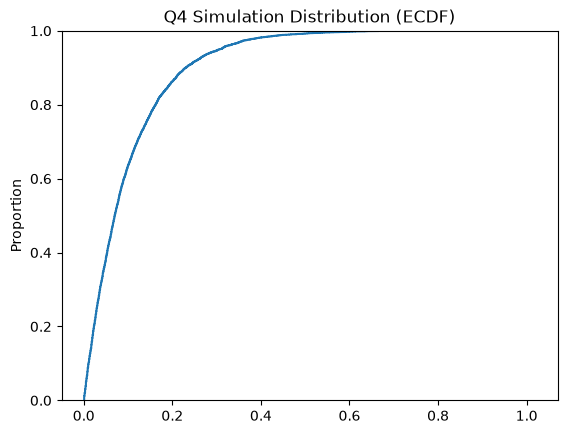

In [6]:
# defining given values
n = 5_000
dt = 1e-3
r = 10
# computing the periods from r*dt
periods = np.random.geometric(r * dt, size=n) # using .geometric since this is "first success", aka the first arrival/death here (found with Claude)
draws = periods * dt
sns.ecdfplot(x=draws)
plt.title("Q4 Simulation Distribution (ECDF)")
plt.show()

ANSWER:

When dt is larger, we get more of a "step" looking concave curve where the steps start large and then get smaller. As dt gets smaller, the "steps" start to disappear and smooth out to look like a concave curve that starts by increasing very fast when x=0 and then slowing down in acceleration as x gets larger.

As r increases, the x-axis beings to shrink while the curve looks to remains the same and y-values remain unchanged (since proportion is always 0-1). So, this means that as r increases, we jump up in y-values faster so we approach the plateau of proportion=1 faster. This makes sense because r is used to compute the periods, so incrasing r means that the arrivals come faster, explaining why we jump up faster in y-values meaning that we get arrivals faster.

Now looking into which distribution this matches, as dt goes to 0 and the steps smooth, we start to match the Exponential Distribution CDF. We can see from the graphs before the problem that they match, mostly because of the super fast initial acceleration that only decelerates but always has a positive slope that plateaus as we approach 1 for the proportion/y-axis. However, it still looks similar to the Beta and Pareto Distribution, but the story here matches the Exponential Distribution because it is all about "arrivals" which are memoryless. In a more mathematical appraoch, the probability of surviving K periods is: 
$$ P(\text{survive k periods}) = (1 - r*dt)^k$$

Converting this into time using k * dt = t, we get: 
 $$(1 - r * dt)^{\frac{t}{dt}}$$
 
We can set a= r * dt to rewrite this to be:
$$(1 - a)^{r * \frac{t}{a}} = [ (1 - a)^{\frac{1}{a}}]^{r * t}$$

What this has now done is that is have moved all the time component pieces to the outside, so as dt goes to 0 and we take the log of this expression, a also goes to 0 and this expression approaches e^-1. This is because for tiny a, ln(1 − a) is approximately −a, so:
$$\frac{1}{a}·ln(1 − a) = \frac{1}{a} * -a \approx -1$$

Going back to our initial equation:
$$(1 - a)^{(r * \frac{t}{a})} = [ (1 - a)^{(\frac{1}{a})} ]^{r * t} \rightarrow{} (e^{-1})^{r * t} = e^{-r * t}$$

Lastly, this is the survival function since we are looking at the probability of surviving K periods, and converting this into a CDF we get 1 - survival function --> 1- e^(-r * t) and this is exactly the CDF of the Exponential Distribution, so that is the match for this simulation.